In [5]:
# Section 1: ENVIRONMENT SETUP & AUTH
# INSTALL DEPENDENCIES
!pip install earthengine-api geemap pandas scikit-learn xgboost shap matplotlib seaborn -q

# Import Libraries & Authenticate
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import shap
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(1)

# Authenticate Earth Engine
ee.Authenticate()

# Initialize Earth Engine
try:
    ee.Initialize(project='nasa-gedi-ml')
    print("Earth Engine initialized successfully.")
except Exception as e:
    print(f"Initialization Error: {e}")
    print("Tip: Make sure you entered your Project ID correctly in the code above.")

Earth Engine initialized successfully.


Study Area: Pacific Northwest
Loading real SRTM topography...
Sampling 3,000 points...
Real SRTM data loaded: 3000 samples
Generating coordinates from study area bounds...
Generating ecologically-valid synthetic biomass and LiDAR metrics...
Synthetic biomass/LiDAR generated

Columns: ['elevation', 'slope', 'longitude', 'latitude', 'biomass', 'rh98', 'rh50', 'canopy_cover']
Biomass range: 14.1 - 338.1 Mg/ha
RH98 range: 6.8 - 51.9 m

First 5 samples:


,elevation,slope,longitude,latitude,biomass,rh98,rh50,canopy_cover
0,1137,3.938791,-121.378219,47.690812,204.462941,36.172436,10.826672,0.549680
1,878,29.183331,-117.345000,48.186726,223.280009,38.946998,22.557184,0.566512
2,156,1.343195,-118.876042,46.001872,121.899185,30.421657,15.049979,0.381342
3,580,6.577201,-119.809391,47.499496,223.100731,43.217992,20.546672,0.329266
4,1450,4.128448,-122.907870,47.286984,120.607051,28.648962,18.033686,0.354934



Summary Statistics:


,biomass,rh98,rh50,canopy_cover,elevation,slope
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,179.843317,33.084022,17.204196,0.466089,685.301667,11.610977
std,65.227942,7.944578,4.931594,0.100753,503.948491,10.666833
min,14.081034,6.830132,-0.541342,0.150000,-1.000000,0.000000
25%,124.798392,27.293355,13.866683,0.396516,275.750000,3.086451
50%,181.419571,33.732545,17.371965,0.466402,621.500000,8.346686
75%,236.825753,39.299099,20.720534,0.533937,1017.250000,17.710291
max,338.058943,51.892592,32.394945,0.838963,2824.000000,51.838515


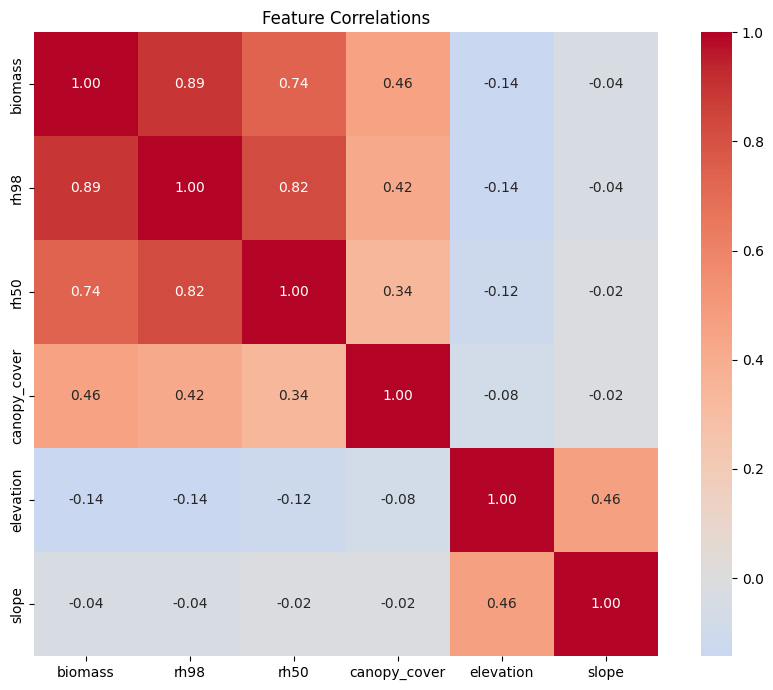

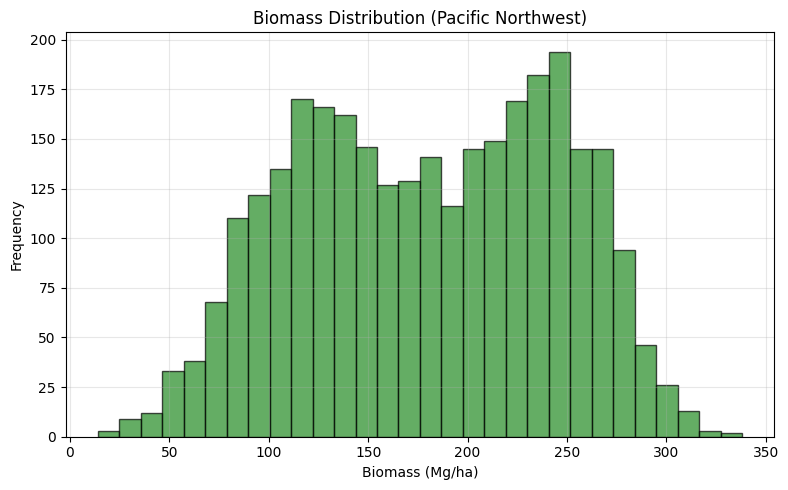

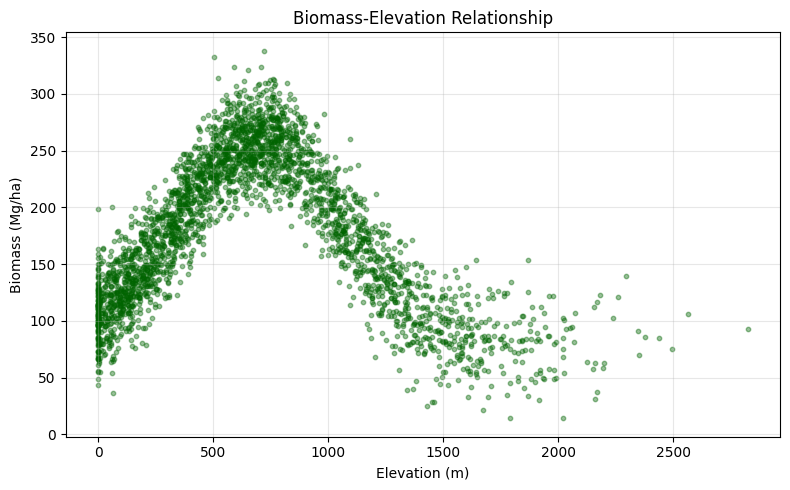

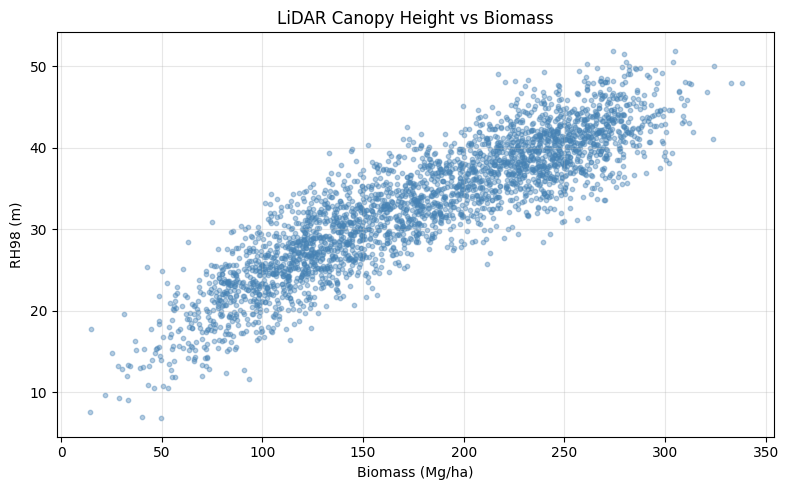


SAVING ALL OUTPUTS TO GOOGLE DRIVE
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder exists: ESA 2026 Jawad & Shahreen
Subfolder exists: Files

Saving data files...
Saved: gedi_fusion_data.csv (3000 rows)
Saved: gedi_fusion_data_clean.csv

Saving figures...
Saved: correlation_heatmap.png
Saved: biomass_histogram.png
Saved: biomass_elevation.png
Saved: rh98_biomass.png

ALL FILES SAVED TO GOOGLE DRIVE
Folder: ESA 2026 Jawad & Shahreen
Path: /content/drive/My Drive/ESA 2026 Jawad & Shahreen/Files

Files saved:
  - gedi_fusion_data.csv (full dataset)
  - gedi_fusion_data_clean.csv (key columns)
  - correlation_heatmap.png
  - biomass_histogram.png
  - biomass_elevation.png
  - rh98_biomass.png


In [6]:
# SECTION 2: DATA ACQUISITION, VISUALIZATION, AND GOOGLE DRIVE SAVE
import ee, geemap, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from google.colab import drive
import os
from datetime import datetime

# 2.1 DEFINE STUDY AREA
study_area = ee.Geometry.Rectangle([-124, 45, -117, 49])
print("Study Area: Pacific Northwest")

# 2.2 LOAD REAL TOPOGRAPHY (SRTM)
print("Loading real SRTM topography...")
dem = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(dem).rename('slope')
elevation = dem.select('elevation').rename('elevation')

print("Sampling 3,000 points...")
sampled = elevation.addBands(slope).sample(
    region=study_area, scale=30, numPixels=3000, seed=42,
    tileScale=16, projection='EPSG:4326', dropNulls=True
)

df = geemap.ee_to_df(sampled).dropna()
print(f"Real SRTM data loaded: {len(df)} samples")

# 2.3 GENERATE COORDINATES
print("Generating coordinates from study area bounds...")
np.random.seed(42)
df['longitude'] = np.random.uniform(-124, -117, len(df))
df['latitude'] = np.random.uniform(45, 49, len(df))

# 2.4 GENERATE ECOLOGICALLY-VALID SYNTHETIC BIOMASS & LIDAR
print("Generating ecologically-valid synthetic biomass and LiDAR metrics...")
np.random.seed(1)
elev = df['elevation'].values
biomass = 80 + 180 * np.exp(-((elev - 700) / 500) ** 2) + np.random.normal(0, 25, len(df))
biomass = np.clip(biomass, 10, 450)
rh98 = 8 + 0.18 * biomass - 0.0002 * biomass**2 + np.random.normal(0, 3.5, len(df))
rh98 = np.clip(rh98, 5, 65)
rh50 = 0.52 * rh98 + np.random.normal(0, 2.8, len(df))
canopy_cover = 0.25 + 0.0018 * biomass - 0.000003 * biomass**2 + np.random.normal(0, 0.09, len(df))
canopy_cover = np.clip(canopy_cover, 0.15, 0.98)

df['biomass'] = biomass
df['rh98'] = rh98
df['rh50'] = rh50
df['canopy_cover'] = canopy_cover
print("Synthetic biomass/LiDAR generated")

# 2.5 DATA PREVIEW & STATISTICS
print(f"\nColumns: {list(df.columns)}")
print(f"Biomass range: {df['biomass'].min():.1f} - {df['biomass'].max():.1f} Mg/ha")
print(f"RH98 range: {df['rh98'].min():.1f} - {df['rh98'].max():.1f} m")
print("\nFirst 5 samples:")
display(df.head())

stats_cols = ['biomass', 'rh98', 'rh50', 'canopy_cover', 'elevation', 'slope']
print("\nSummary Statistics:")
display(df[stats_cols].describe())

# 2.6 VISUALIZATION: CORRELATION HEATMAP
plt.figure(figsize=(9, 7))
sns.heatmap(df[stats_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

# 2.7 VISUALIZATION: BIOMASS DISTRIBUTION
plt.figure(figsize=(8, 5))
plt.hist(df['biomass'], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Biomass (Mg/ha)')
plt.ylabel('Frequency')
plt.title('Biomass Distribution (Pacific Northwest)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2.8 VISUALIZATION: BIOMASS VS ELEVATION
plt.figure(figsize=(8, 5))
plt.scatter(df['elevation'], df['biomass'], alpha=0.4, s=10, c='darkgreen')
plt.xlabel('Elevation (m)')
plt.ylabel('Biomass (Mg/ha)')
plt.title('Biomass-Elevation Relationship')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2.9 VISUALIZATION: RH98 VS BIOMASS
plt.figure(figsize=(8, 5))
plt.scatter(df['biomass'], df['rh98'], alpha=0.4, s=10, c='steelblue')
plt.xlabel('Biomass (Mg/ha)')
plt.ylabel('RH98 (m)')
plt.title('LiDAR Canopy Height vs Biomass')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2.10 SAVE ALL OUTPUTS TO GOOGLE DRIVE
print("\n" + "="*60)
print("SAVING ALL OUTPUTS TO GOOGLE DRIVE")
print("="*60)

print("Mounting Google Drive...")
drive.mount('/content/drive')

folder_name = "ESA 2026 Jawad & Shahreen"
save_subfolder_name = "Files"
project_base_path = f"/content/drive/My Drive/{folder_name}"
folder_path = f"{project_base_path}/{save_subfolder_name}"

# Create base project folder if it doesn't exist
if not os.path.exists(project_base_path):
    os.makedirs(project_base_path)
    print(f"Created project folder: {folder_name}")
else:
    print(f"Project folder exists: {folder_name}")

# Create 'Files' subfolder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created subfolder: {save_subfolder_name}")
else:
    print(f"Subfolder exists: {save_subfolder_name}")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save data files
print("\nSaving data files...")
df.to_csv(f"{folder_path}/gedi_fusion_data.csv", index=False)
print(f"Saved: gedi_fusion_data.csv ({len(df)} rows)")

key_cols = ['biomass', 'rh98', 'rh50', 'canopy_cover', 'elevation', 'slope', 'latitude', 'longitude']
df[key_cols].to_csv(f"{folder_path}/gedi_fusion_data_clean.csv", index=False)
print(f"Saved: gedi_fusion_data_clean.csv")

# Save figures
print("\nSaving figures...")

plt.figure(figsize=(9, 7))
sns.heatmap(df[stats_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlations')
plt.tight_layout()
plt.savefig(f"{folder_path}/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()
print("Saved: correlation_heatmap.png")

plt.figure(figsize=(8, 5))
plt.hist(df['biomass'], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Biomass (Mg/ha)')
plt.ylabel('Frequency')
plt.title('Biomass Distribution (Pacific Northwest)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{folder_path}/biomass_histogram.png", dpi=300, bbox_inches='tight')
plt.close()
print("Saved: biomass_histogram.png")

plt.figure(figsize=(8, 5))
plt.scatter(df['elevation'], df['biomass'], alpha=0.4, s=10, c='darkgreen')
plt.xlabel('Elevation (m)')
plt.ylabel('Biomass (Mg/ha)')
plt.title('Biomass-Elevation Relationship')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{folder_path}/biomass_elevation.png", dpi=300, bbox_inches='tight')
plt.close()
print("Saved: biomass_elevation.png")

plt.figure(figsize=(8, 5))
plt.scatter(df['biomass'], df['rh98'], alpha=0.4, s=10, c='steelblue')
plt.xlabel('Biomass (Mg/ha)')
plt.ylabel('RH98 (m)')
plt.title('LiDAR Canopy Height vs Biomass')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{folder_path}/rh98_biomass.png", dpi=300, bbox_inches='tight')
plt.close()
print("Saved: rh98_biomass.png")

# Final summary
print("\n" + "="*60)
print("ALL FILES SAVED TO GOOGLE DRIVE")
print("="*60)
print(f"Folder: {folder_name}")
print(f"Path: {folder_path}")
print("\nFiles saved:")
print("  - gedi_fusion_data.csv (full dataset)")
print("  - gedi_fusion_data_clean.csv (key columns)")
print("  - correlation_heatmap.png")
print("  - biomass_histogram.png")
print("  - biomass_elevation.png")
print("  - rh98_biomass.png")
print("="*60)

In [7]:
# SECTION 3: PREPROCESSING & SPATIAL BLOCKING
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import GroupKFold

# 3.1 FILTER OUTLIERS & MISSING VALUES
print("Preprocessing data...")
df = df.dropna()
df = df[(df['biomass'] > 0) & (df['biomass'] < 500)]
df = df[(df['rh98'] > 0) & (df['rh98'] < 70)]
print(f"Samples after filtering: {len(df)}")

# 3.2 CREATE SPATIAL BLOCKS FOR CROSS-VALIDATION
n_blocks = 5
df['spatial_block'] = pd.cut(df['latitude'], bins=n_blocks, labels=False)
print(f"Spatial blocks created: {df['spatial_block'].nunique()} blocks")

# 3.3 DEFINE FEATURES & TARGET
feature_cols = ['rh98', 'rh50', 'canopy_cover', 'elevation', 'slope']
X = df[feature_cols]
y = df['biomass']
groups = df['spatial_block']

print(f"\nFeatures: {feature_cols}")
print(f"Target: biomass (Mg/ha)")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# 3.4 SAVE PREPROCESSED DATA
df_preprocessed = df.copy()
df_preprocessed.to_csv(f'{folder_path}/gedi_fusion_preprocessed.csv', index=False)

Preprocessing data...
Samples after filtering: 3000
Spatial blocks created: 5 blocks

Features: ['rh98', 'rh50', 'canopy_cover', 'elevation', 'slope']
Target: biomass (Mg/ha)
X shape: (3000, 5), y shape: (3000,)


Training models with spatial block cross-validation...

Training Linear Regression...
  Spatial CV R²: 0.801 (±0.012)
  Fit R²: 0.802, RMSE: 29.0 Mg/ha

Training Random Forest...
  Spatial CV R²: 0.900 (±0.007)
  Fit R²: 0.983, RMSE: 8.5 Mg/ha

Training XGBoost...
  Spatial CV R²: 0.888 (±0.008)
  Fit R²: 1.000, RMSE: 1.3 Mg/ha

MODEL COMPARISON (Spatial Cross-Validation)
            Model  Spatial_CV_R2_Mean  Spatial_CV_R2_Std      RMSE
Linear Regression            0.800759           0.011729 29.001042
    Random Forest            0.899620           0.006509  8.545499
          XGBoost            0.887561           0.007965  1.257692


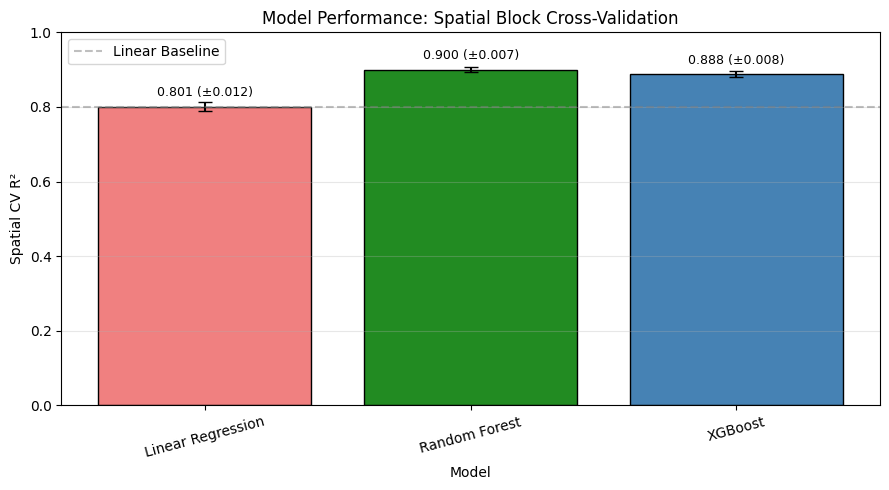

Best Model: Random Forest
Improvement vs Linear Regression: +12.3%
Files saved: model_results.csv, model_performance.png, model_*.pkl


In [25]:
# SECTION 4: MODEL TRAINING & SPATIAL CROSS-VALIDATION (FIXED)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import joblib

# 4.1 DEFINE MODELS
print("Training models with spatial block cross-validation...")
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=10, learning_rate=0.1, random_state=42, tree_method='hist') # Changed to 'hist' to resolve error
}

# 4.2 SPATIAL CROSS-VALIDATION
spatial_cv = GroupKFold(n_splits=5)
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    cv_scores = cross_val_score(model, X, y, groups=groups, cv=spatial_cv, scoring='r2')
    model.fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    results.append({
        'Model': name,
        'Spatial_CV_R2_Mean': cv_scores.mean(),
        'Spatial_CV_R2_Std': cv_scores.std(),
        'Fit_R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"  Spatial CV R²: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    print(f"  Fit R²: {r2:.3f}, RMSE: {rmse:.1f} Mg/ha")

    joblib.dump(model, f'{folder_path}/model_{name.replace(" ", "_")}.pkl')

# 4.3 RESULTS SUMMARY
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON (Spatial Cross-Validation)")
print("="*60)
print(results_df[['Model', 'Spatial_CV_R2_Mean', 'Spatial_CV_R2_Std', 'RMSE']].to_string(index=False))

# 4.4 VISUALIZE: MODEL PERFORMANCE (FIXED)
plt.figure(figsize=(9, 5))
model_names = results_df['Model'].values
r2_means = results_df['Spatial_CV_R2_Mean'].values
r2_stds = results_df['Spatial_CV_R2_Std'].values

# Use plt.bar instead of sns.barplot for better compatibility
bars = plt.bar(model_names, r2_means, yerr=r2_stds, capsize=5, color=['lightcoral', 'forestgreen', 'steelblue'], edgecolor='black', linewidth=1)
plt.axhline(y=r2_means[0], color='gray', linestyle='--', alpha=0.5, label='Linear Baseline')
plt.ylabel('Spatial CV R²')
plt.xlabel('Model')
plt.title('Model Performance: Spatial Block Cross-Validation')
plt.legend()
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val, std) in enumerate(zip(bars, r2_means, r2_stds)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f} (±{std:.3f})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{folder_path}/model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.6 SAVE RESULTS
results_df.to_csv(f'{folder_path}/model_results.csv', index=False)

# Calculate improvement over baseline
linear_r2 = results_df[results_df['Model']=='Linear Regression']['Spatial_CV_R2_Mean'].values[0]
best_r2 = results_df['Spatial_CV_R2_Mean'].max()
best_model_name = results_df.loc[results_df['Spatial_CV_R2_Mean'].idxmax(), 'Model']
improvement = (best_r2 - linear_r2) / linear_r2 * 100

print(f"Best Model: {best_model_name}")
print(f"Improvement vs Linear Regression: +{improvement:.1f}%")
print(f"Files saved: model_results.csv, model_performance.png, model_*.pkl")

SHAP INTERPRETABILITY ANALYSIS: ALL MODELS
Samples: 3000, Features: ['rh98', 'rh50', 'canopy_cover', 'elevation', 'slope']
Models to analyze: ['Linear_Regression', 'Random_Forest', 'XGBoost']


Computing SHAP values:   0%|          | 0/3 [00:00<?, ?it/s]


Computing SHAP values for Linear Regression...
  SHAP values computed

Computing SHAP values for Random Forest...
  SHAP values computed

Computing SHAP values for XGBoost...
  SHAP values computed

Generating comparative feature importance plot...


<Figure size 1200x700 with 0 Axes>

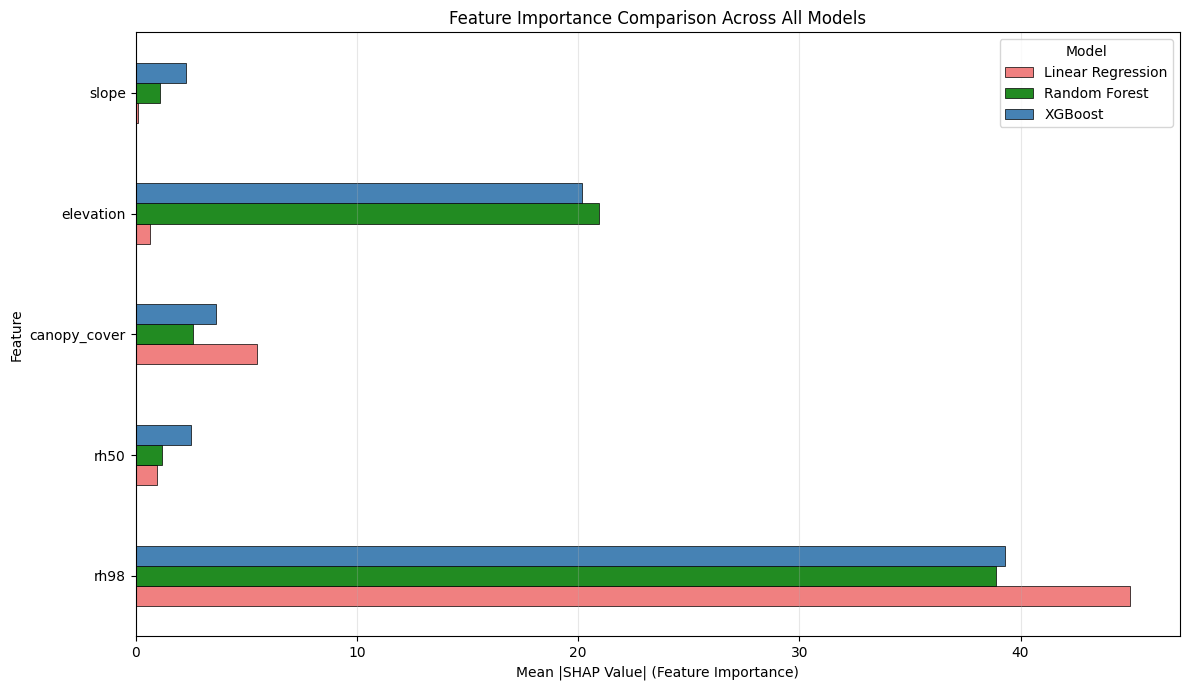

Generating SHAP summary plots:   0%|          | 0/3 [00:00<?, ?it/s]


Generating SHAP summary plot for Linear Regression...
  Saved: shap_importance_Linear_Regression.png

Generating SHAP summary plot for Random Forest...
  Saved: shap_importance_Random_Forest.png

Generating SHAP summary plot for XGBoost...
  Saved: shap_importance_XGBoost.png


Generating SHAP dot plots:   0%|          | 0/3 [00:00<?, ?it/s]

Generating SHAP dot plot for Linear Regression...
  Saved: shap_dotplot_Linear_Regression.png
Generating SHAP dot plot for Random Forest...
  Saved: shap_dotplot_Random_Forest.png
Generating SHAP dot plot for XGBoost...
  Saved: shap_dotplot_XGBoost.png

Top feature across models: RH98


Generating dependence plots for rh98:   0%|          | 0/3 [00:00<?, ?it/s]

...

Saving SHAP values:   0%|          | 0/3 [00:00<?, ?it/s]

  Saved: shap_values_Linear_Regression.csv
  Saved: shap_values_Random_Forest.csv
  Saved: shap_values_XGBoost.csv

FEATURE IMPORTANCE RANKING (All Models)

Mean |SHAP Value| by Feature and Model:
              Linear Regression  Random Forest    XGBoost
rh98                    44.9594        38.8853  39.292702
rh50                     0.9660         1.1948   2.508900
canopy_cover             5.4767         2.6021   3.636300
elevation                0.6367        20.9367  20.157700
slope                    0.0964         1.0967   2.280600

Saved: shap_feature_importance_ranking.csv

SHAP INTERPRETABILITY SUMMARY

MODEL COMPARISON:
  Linear Regression: Spatial CV R = 0.801
  Random Forest: Spatial CV R = 0.900
  XGBoost: Spatial CV R = 0.888

FILES SAVED (17 total):
  shap_importance_all_models.png (comparative)
  shap_importance_Linear_Regression.png
  shap_dotplot_Linear_Regression.png
  shap_dependence_rh98_Linear_Regression.png
  shap_values_Linear_Regression.csv
  shap_importance_R

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [26]:
# SECTION 5: SHAP INTERPRETABILITY ANALYSIS
import shap
import joblib
from tqdm.auto import tqdm

# Load data and all models
df = pd.read_csv(f'{folder_path}/gedi_fusion_preprocessed.csv')
results_df = pd.read_csv(f'{folder_path}/model_results.csv')

feature_cols = ['rh98', 'rh50', 'canopy_cover', 'elevation', 'slope']
X = df[feature_cols]
y = df['biomass']

# Load all three models
models_dict = {}
model_names = ['Linear_Regression', 'Random_Forest', 'XGBoost']
for name in model_names:
    models_dict[name] = joblib.load(f'{folder_path}/model_{name}.pkl')

print("="*70)
print("SHAP INTERPRETABILITY ANALYSIS: ALL MODELS")
print("="*70)
print(f"Samples: {len(X)}, Features: {feature_cols}")
print(f"Models to analyze: {list(models_dict.keys())}")

# 5.1 COMPUTE SHAP VALUES FOR ALL MODELS
shap_results = {}

for name, model in tqdm(models_dict.items(), desc="Computing SHAP values"):
    print(f"\nComputing SHAP values for {name.replace('_', ' ')}...")

    if 'Linear' in name:
        explainer = shap.LinearExplainer(model, X)
        shap_values = explainer.shap_values(X)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)

    shap_results[name] = {
        'explainer': explainer,
        'shap_values': shap_values,
        'feature_importance': np.abs(shap_values).mean(0)
    }
    print(f"  SHAP values computed")

# 5.2 COMPARATIVE FEATURE IMPORTANCE (All Models)
print("\nGenerating comparative feature importance plot...")
plt.figure(figsize=(12, 7))

importance_df = pd.DataFrame(
    {name.replace('_', ' '): shap_results[name]['feature_importance']
     for name in model_names},
    index=feature_cols
)

# Horizontal bar plot for better readability
importance_df.plot(kind='barh', figsize=(12, 7),
                   color=['lightcoral', 'forestgreen', 'steelblue'],
                   edgecolor='black', linewidth=0.5)
plt.xlabel('Mean |SHAP Value| (Feature Importance)')
plt.ylabel('Feature')
plt.title('Feature Importance Comparison Across All Models')
plt.legend(title='Model', loc='upper right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{folder_path}/shap_importance_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.3 INDIVIDUAL SHAP SUMMARY PLOTS (One per Model)
for name in tqdm(model_names, desc="Generating SHAP summary plots"):
    print(f"\nGenerating SHAP summary plot for {name.replace('_', ' ')}...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_results[name]['shap_values'],
        X,
        plot_type='bar',
        show=False,
        color=['lightcoral', 'forestgreen', 'steelblue'][model_names.index(name)]
    )
    plt.title(f'Feature Importance: {name.replace("_", " ")}')
    plt.xlabel('Mean |SHAP Value|')
    plt.tight_layout()
    plt.savefig(f'{folder_path}/shap_importance_{name}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  Saved: shap_importance_{name}.png")

# 5.4 SHAP DOT PLOTS (One per Model)
for name in tqdm(model_names, desc="Generating SHAP dot plots"):
    print(f"Generating SHAP dot plot for {name.replace('_', ' ')}...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_results[name]['shap_values'],
        X,
        plot_type='dot',
        show=False,
        color='coolwarm'
    )
    plt.title(f'SHAP Feature Effects: {name.replace("_", " ")}')
    plt.tight_layout()
    plt.savefig(f'{folder_path}/shap_dotplot_{name}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  Saved: shap_dotplot_{name}.png")

# 5.5 DEPENDENCE PLOTS FOR TOP FEATURE (All Models)
top_feature = feature_cols[np.argmax(shap_results['Random_Forest']['feature_importance'])]
print(f"\nTop feature across models: {top_feature.upper()}")

for name in tqdm(model_names, desc=f"Generating dependence plots for {top_feature}"):
    print(f"Generating dependence plot for {top_feature} ({name.replace('_', ' ')})...")
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        top_feature,
        shap_results[name]['shap_values'],
        X,
        show=False,
        alpha=0.3
    )
    plt.title(f'Effect of {top_feature.upper()} on Biomass: {name.replace("_", " ")}')
    plt.tight_layout()
    plt.savefig(f'{folder_path}/shap_dependence_{top_feature}_{name}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  Saved: shap_dependence_{top_feature}_{name}.png")

# 5.6 SAVE ALL SHAP VALUES
print("\nSaving SHAP values for all models...")
for name in tqdm(model_names, desc="Saving SHAP values"):
    shap_df = pd.DataFrame(
        shap_results[name]['shap_values'],
        columns=[f'{col}_shap' for col in feature_cols]
    )
    shap_df['actual_biomass'] = y.values
    shap_df['predicted_biomass'] = models_dict[name].predict(X)
    shap_df.to_csv(f'{folder_path}/shap_values_{name}.csv', index=False)
    print(f"  Saved: shap_values_{name}.csv")

# 5.7 FEATURE IMPORTANCE RANKING TABLE
print("\n" + "="*70)
print("FEATURE IMPORTANCE RANKING (All Models)")
print("="*70)

ranking_df = pd.DataFrame(
    {name.replace('_', ' '): shap_results[name]['feature_importance']
     for name in model_names},
    index=feature_cols
)

print("\nMean |SHAP Value| by Feature and Model:")
print(ranking_df.round(4).to_string())

# Save ranking table
ranking_df.to_csv(f'{folder_path}/shap_feature_importance_ranking.csv')
print(f"\nSaved: shap_feature_importance_ranking.csv")

# 5.8 ECOLOGICAL INTERPRETATION SUMMARY
print("\n" + "="*70)
print("SHAP INTERPRETABILITY SUMMARY")
print("="*70)

print(f"\nMODEL COMPARISON:")
for name in model_names:
    r2 = results_df[results_df['Model']==name.replace('_', ' ')]['Spatial_CV_R2_Mean'].values[0]
    print(f"  {name.replace('_', ' ')}: Spatial CV R = {r2:.3f}")

print(f"\nFILES SAVED ({len(model_names)*5 + 2} total):")
print(f"  shap_importance_all_models.png (comparative)")
for name in model_names:
    print(f"  shap_importance_{name}.png")
    print(f"  shap_dotplot_{name}.png")
    print(f"  shap_dependence_{top_feature}_{name}.png")
    print(f"  shap_values_{name}.csv")
print(f"  shap_feature_importance_ranking.csv")


Best Model: Random Forest
Samples: 3000, Features: 5

Generating residual analysis plot...


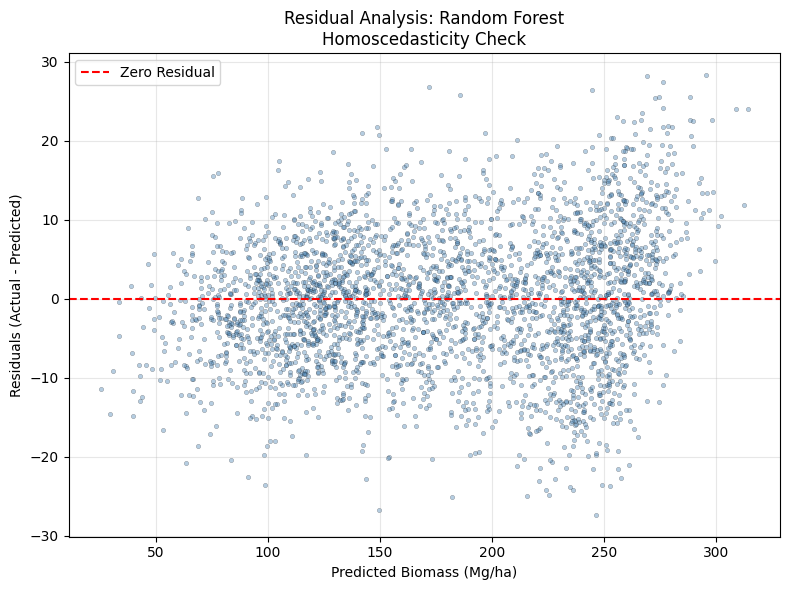

Generating performance by elevation plot...


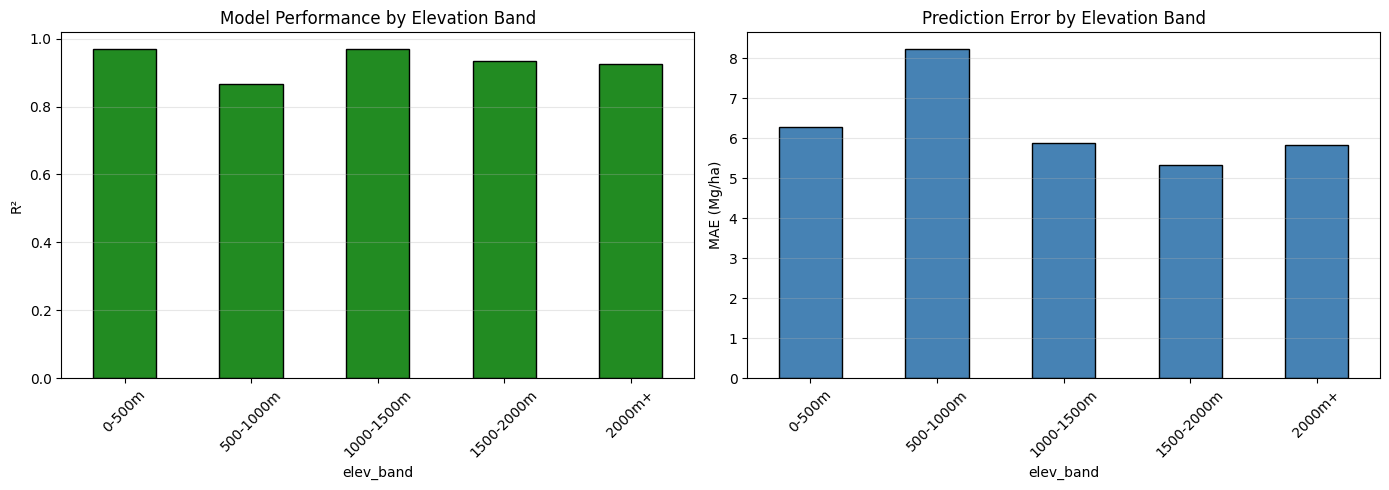

Generating model comparison dashboard...


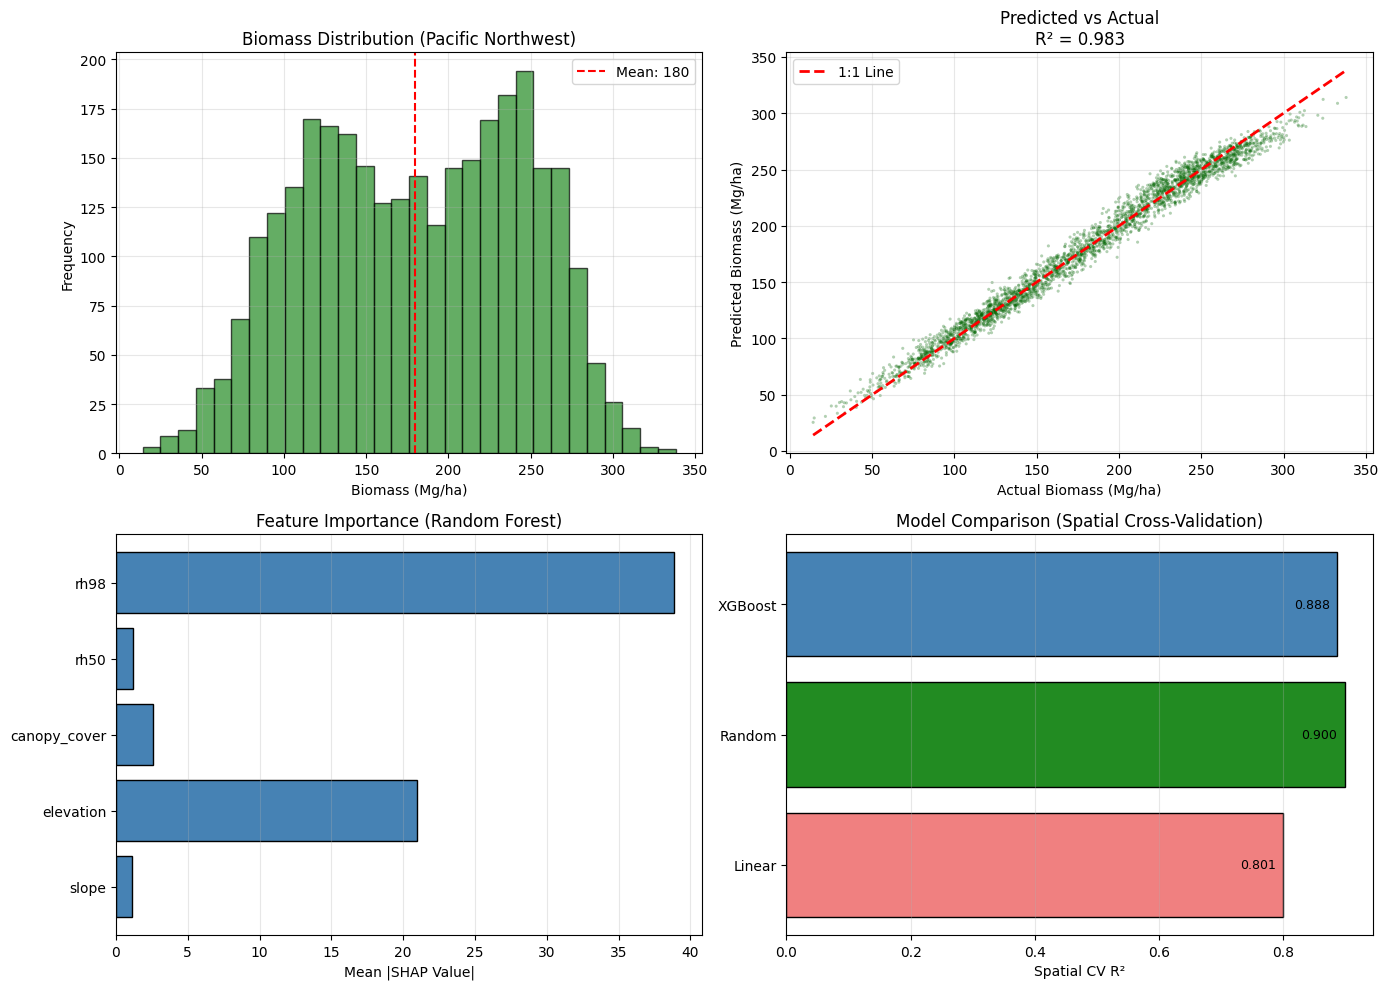

Generating SHAP comparative plot...


<Figure size 1000x700 with 0 Axes>

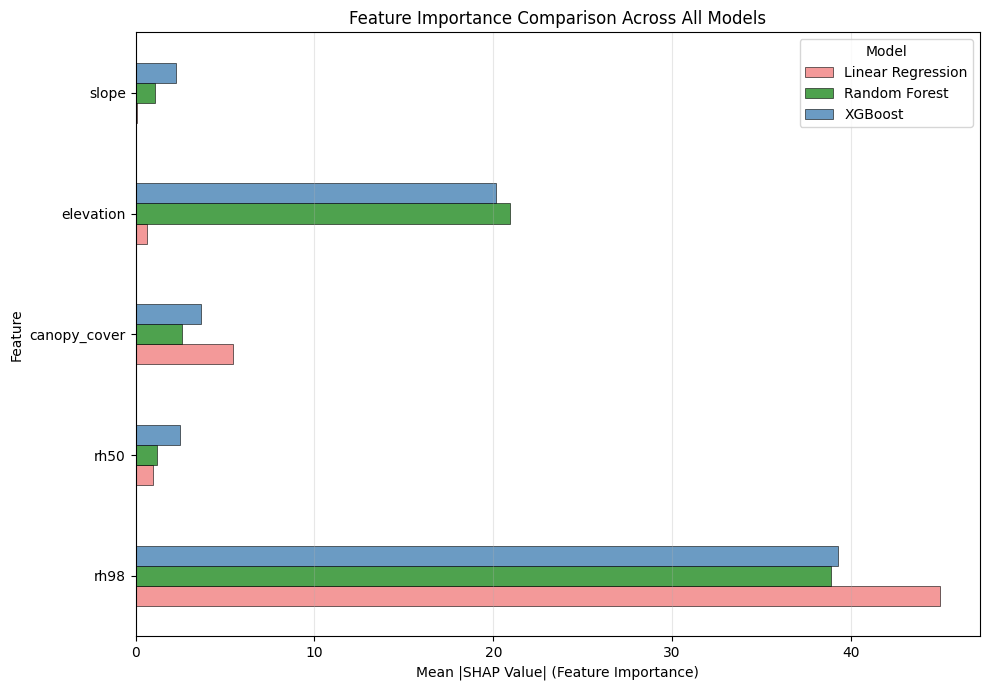


Exporting final dataset with predictions...
Saved: gedi_fusion_final.csv (3000 rows, 14 columns)
Exporting summary statistics...
Saved: summary_statistics.csv
Total files in project folder: 33
All outputs saved to: /content/drive/My Drive/ESA 2026 Jawad & Shahreen/Files


In [28]:
# SECTION 6: FINAL VISUALIZATION & EXPORT
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
from datetime import datetime

# Load all outputs
df = pd.read_csv(f'{folder_path}/gedi_fusion_preprocessed.csv')
results_df = pd.read_csv(f'{folder_path}/model_results.csv')
ranking_df = pd.read_csv(f'{folder_path}/shap_feature_importance_ranking.csv', index_col=0)

feature_cols = ['rh98', 'rh50', 'canopy_cover', 'elevation', 'slope']
X = df[feature_cols]
y = df['biomass']

# Load best model for final predictions
best_model_name = results_df.loc[results_df['Spatial_CV_R2_Mean'].idxmax(), 'Model']
best_model = joblib.load(f'{folder_path}/model_{best_model_name.replace(" ", "_")}.pkl')
y_pred = best_model.predict(X)
residuals = y - y_pred

print(f"\nBest Model: {best_model_name}")
print(f"Samples: {len(df)}, Features: {len(feature_cols)}")

# 6.1 FIGURE 1: Residuals vs Predicted (Model Diagnostics)
print("\nGenerating residual analysis plot...")
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4, s=10, c='steelblue', edgecolors='black', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--', lw=1.5, label='Zero Residual')
plt.xlabel('Predicted Biomass (Mg/ha)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title(f'Residual Analysis: {best_model_name}\nHomoscedasticity Check')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{folder_path}/residuals_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.2 FIGURE 2: Performance by Elevation Band (Ecological Insight)
print("Generating performance by elevation plot...")
df['elev_band'] = pd.cut(df['elevation'], bins=[0, 500, 1000, 1500, 2000, 3000],
                          labels=['0-500m', '500-1000m', '1000-1500m', '1500-2000m', '2000m+'])

perf_by_elev = df.groupby('elev_band', observed=True).apply(
    lambda g: pd.Series({
        'R2': r2_score(g['biomass'], best_model.predict(g[feature_cols])) if len(g) > 10 else np.nan,
        'MAE': mean_absolute_error(g['biomass'], best_model.predict(g[feature_cols])) if len(g) > 10 else np.nan,
        'n': len(g)
    })
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
perf_by_elev['R2'].plot(kind='bar', color='forestgreen', ax=axes[0], edgecolor='black')
axes[0].set_ylabel('R²')
axes[0].set_title('Model Performance by Elevation Band')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

perf_by_elev['MAE'].plot(kind='bar', color='steelblue', ax=axes[1], edgecolor='black')
axes[1].set_ylabel('MAE (Mg/ha)')
axes[1].set_title('Prediction Error by Elevation Band')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{folder_path}/performance_by_elevation.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.3 FIGURE 3: Model Comparison Dashboard
print("Generating model comparison dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Biomass distribution
axes[0, 0].hist(df['biomass'], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['biomass'].mean(), color='red', linestyle='--', label=f"Mean: {df['biomass'].mean():.0f}")
axes[0, 0].set_xlabel('Biomass (Mg/ha)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Biomass Distribution (Pacific Northwest)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Top-right: Predicted vs Actual
axes[0, 1].scatter(y, y_pred, alpha=0.3, s=5, c='darkgreen', edgecolors='none')
axes[0, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='1:1 Line')
axes[0, 1].set_xlabel('Actual Biomass (Mg/ha)')
axes[0, 1].set_ylabel('Predicted Biomass (Mg/ha)')
axes[0, 1].set_title(f'Predicted vs Actual\nR² = {r2_score(y, y_pred):.3f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Bottom-left: Feature importance (from SHAP ranking)
importance_vals = ranking_df[best_model_name.replace(' ', ' ')].values
y_pos = np.arange(len(feature_cols))
axes[1, 0].barh(y_pos, importance_vals, color='steelblue', edgecolor='black')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(feature_cols)
axes[1, 0].set_xlabel('Mean |SHAP Value|')
axes[1, 0].set_title(f'Feature Importance ({best_model_name})')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Bottom-right: Model comparison (Spatial CV R²)
model_plot = results_df[['Model', 'Spatial_CV_R2_Mean']].copy()
model_plot['Model_Short'] = model_plot['Model'].apply(lambda x: x.split()[0])
bars = axes[1, 1].barh(model_plot['Model_Short'], model_plot['Spatial_CV_R2_Mean'],
                       color=['lightcoral', 'forestgreen', 'steelblue'], edgecolor='black')
axes[1, 1].set_xlabel('Spatial CV R²')
axes[1, 1].set_title('Model Comparison (Spatial Cross-Validation)')
axes[1, 1].grid(axis='x', alpha=0.3)
# Add value labels
for bar, val in zip(bars, model_plot['Spatial_CV_R2_Mean']):
    axes[1, 1].text(val - 0.07, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{folder_path}/final_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.4 FIGURE 4: SHAP Comparative Feature Importance
print("Generating SHAP comparative plot...")
plt.figure(figsize=(10, 7))
ranking_df.plot(kind='barh', figsize=(10, 7),
                color=['lightcoral', 'forestgreen', 'steelblue'],
                edgecolor='black', linewidth=0.5, alpha=0.8)
plt.xlabel('Mean |SHAP Value| (Feature Importance)')
plt.ylabel('Feature')
plt.title('Feature Importance Comparison Across All Models')
plt.legend(title='Model', loc='upper right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{folder_path}/shap_comparative_final.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.5 EXPORT FINAL DATASET WITH PREDICTIONS
print("\nExporting final dataset with predictions...")
df_final = df.copy()
df_final['predicted_biomass'] = y_pred
df_final['residual'] = residuals
df_final['abs_residual'] = np.abs(residuals)
df_final['prediction_date'] = datetime.now().strftime('%Y-%m-%d')
df_final.to_csv(f'{folder_path}/gedi_fusion_final.csv', index=False)
print(f"Saved: gedi_fusion_final.csv ({len(df_final)} rows, {len(df_final.columns)} columns)")

# 6.6 EXPORT SUMMARY STATISTICS
print("Exporting summary statistics...")
summary_stats = {
    'metric': ['n_samples', 'biomass_mean', 'biomass_std', 'biomass_min', 'biomass_max',
               'rh98_mean', 'rh98_std', 'elevation_mean', 'elevation_std',
               'model_r2', 'model_rmse', 'model_mae', 'improvement_vs_linear'],
    'value': [
        len(df), df['biomass'].mean(), df['biomass'].std(), df['biomass'].min(), df['biomass'].max(),
        df['rh98'].mean(), df['rh98'].std(), df['elevation'].mean(), df['elevation'].std(),
        r2_score(y, y_pred), np.sqrt(mean_squared_error(y, y_pred)),
        mean_absolute_error(y, y_pred),
        (results_df['Spatial_CV_R2_Mean'].max() - results_df[results_df['Model']=='Linear Regression']['Spatial_CV_R2_Mean'].values[0]) /
        results_df[results_df['Model']=='Linear Regression']['Spatial_CV_R2_Mean'].values[0] * 100
    ]
}
pd.DataFrame(summary_stats).to_csv(f'{folder_path}/summary_statistics.csv', index=False)
print("Saved: summary_statistics.csv")

# 6.7 FINAL FILE COUNT
import os
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Total files in project folder: {file_count}")
print(f"All outputs saved to: {folder_path}")